In [2]:

import sys
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import pandas as pd
pd.options.mode.chained_assignment = None
import random
import matplotlib.colors as mcolors
import itertools
from shapely.geometry import Polygon, Point
import multiprocessing as mp
import seaborn as sns

import scipy
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import sklearn
import matplotlib.patches as mpatches
import os
import shutil


In [3]:
# sklearn.neighbors

import sklearn.neighbors

In [4]:
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

# Functions

In [5]:
def angle_groups(vt_df, group_col = "prop_along_group", is_apical_col="is_apical_side_plane", in_soma_col=None, is_radial_remove_col=None):

    groups_present = vt_df[group_col].unique()
    target_basal = 0
    target_apical = np.pi

    data_dict = {"dendrite_type": [], "group_id": [], "angle": []}

    for group_inx, group_id in enumerate(groups_present):
        group_df = vt_df.loc[vt_df[group_col] == group_id]
        if in_soma_col is not None:
            group_df = group_df.loc[~group_df[in_soma_col]]
        if is_radial_remove_col is not None:
            group_df = group_df.loc[~group_df[is_radial_remove_col]]
        apical_df = group_df.loc[group_df[is_apical_col]].copy()
        basal_df = group_df.loc[~group_df[is_apical_col]].copy()
        basal_df.loc[:,"theta_moved"] = add_angles(basal_df["theta"], np.pi)

        med_apical = mean_angles(apical_df["theta"])
        apical_adj = subtract_angles(target_apical, med_apical)

        med_basal = mean_angles(basal_df["theta_moved"])
        basal_adj = subtract_angles(target_apical, med_basal)

        data_dict["dendrite_type"].append("basal")
        data_dict["group_id"].append(group_id)
        data_dict["angle"].append(basal_adj)

        data_dict["dendrite_type"].append("apical")
        data_dict["group_id"].append(group_id)
        data_dict["angle"].append(apical_adj)

        all_thetas = list(apical_df["theta"]) + list(basal_df["theta_moved"])
        median_all = mean_angles(all_thetas)
        median_all = subtract_angles(target_apical, median_all)
        data_dict["dendrite_type"].append("all")
        data_dict["group_id"].append(group_id)
        data_dict["angle"].append(median_all)

    theta_df = pd.DataFrame(data_dict)

    theta_df["is_apical"] = theta_df["dendrite_type"] == "apical"
    theta_df["id_key"] = theta_df["dendrite_type"] + "_" + theta_df["group_id"].astype(str)
    theta_df.index = theta_df["id_key"]
    group_to_theta_dict = theta_df["angle"].to_dict()
    return group_to_theta_dict

def subtract_angles(angle1, angle2):
  diff_rad = angle1 - angle2
  diff_wrapped = np.arctan2(np.sin(diff_rad), np.cos(diff_rad))
  return diff_wrapped

def add_angles(angle1, angle2):
  sum_rad = angle1 + angle2
  sum_wrapped = np.arctan2(np.sin(sum_rad), np.cos(sum_rad))
  return sum_wrapped

def mean_angles(theta_vec):
    x_vals = np.cos(theta_vec)
    y_vals = np.sin(theta_vec)
    mean_x = np.mean(x_vals)
    mean_y = np.mean(y_vals)
    theta_mean = np.arctan2(mean_y, mean_x)
    return theta_mean


def polar_density_plot(point_and_centroid_df, ax=None, theta_col="theta", title="", max_r=None, min_r=None, bins=50, rotation=0, weigh_umis=False, distance_col="distance_from_centroid", vmax=None, vmax_quant=None, remove_angles=False, remove_distances=False, boundaries=[], zorder=0, rasterized=True):
    if ax is None:
        fig = plt.figure(figsize=(6, 6))
        ax = fig.add_subplot(111, projection='polar')
    
    # Convert rotation angle to radians
    rotation_rad = np.radians(rotation)

    point_and_centroid_df_below_max = point_and_centroid_df.loc[point_and_centroid_df[distance_col] <= max_r]
    # Get the distances and angles
    r = point_and_centroid_df[distance_col]
    theta_rad = point_and_centroid_df[theta_col] + rotation_rad  # Apply rotation
    theta_rad = (theta_rad + np.pi) % (2 * np.pi) - np.pi

    hist, theta_edges, r_edges = np.histogram2d(
        theta_rad,
        r,
        bins=[bins, bins],
        range=[[-np.pi, np.pi], [0, max_r if max_r is not None else r.max()]]
    )
    
    hist = hist / hist.sum()
    # Get the centers of the bins
    theta_centers = (theta_edges[:-1] + theta_edges[1:]) / 2
    r_centers = (r_edges[:-1] + r_edges[1:]) / 2
    
    # # Create a meshgrid for plotting
    THETA, R = np.meshgrid(theta_centers, r_centers)

    if vmax_quant is not None:
        vmax = np.quantile(hist, vmax_quant)
        hist = hist / vmax
        vmax = vmax_quant
        
    
    # # Plot the density
    pcm = ax.pcolormesh(THETA, R, hist.T, cmap='viridis', vmax=vmax, rasterized=rasterized, zorder=zorder)
    plt.colorbar(pcm, ax=ax, label='Proportion max density')

    ax.set_zorder(zorder+1)
    ax.set_title(title, fontsize=18)
    ax.set_theta_zero_location('N')
    # # ax.set_theta_zero_location('S')
    ax.set_theta_direction(1)
    ax.set_rlabel_position(315)
    ax.tick_params(axis='y', labelcolor='lightgray')
    ax.patch.set_visible(False)
    if max_r is not None:
        ax.set_rmax(max_r)
    if min_r is not None:
        ax.set_rmin(min_r)

    if remove_angles:
        ax.set_xticks([])
    if remove_distances:
        ax.set_yticks([])

    legend_handles = {}
    for boundary in boundaries:
        name, distance, angle_start, angle_end, color = boundary
        angle_range = np.linspace(angle_start, angle_end, 500)
        line, = ax.plot(angle_range, [distance] * len(angle_range), label=name, linestyle='--', linewidth=2, color=color)
        if name not in legend_handles:
            legend_handles[name] = line

    ax.scatter(0, 0, color='white', s=0, zorder=zorder, label="Origin")
    if len(legend_handles) > 0:
        ax.legend(legend_handles.values(), legend_handles.keys(), loc="upper right")
    


def create_kde_vals(distance_vec, bandwidth=1, eval_inc = 1, min_val=None, max_val=None):
    assert min_val is not None
    assert max_val is not None
    distance_vec = distance_vec.reshape(-1, 1)
    kde = sklearn.neighbors.KernelDensity(bandwidth=bandwidth).fit(distance_vec)
    eval_points = np.arange(min_val, max_val, eval_inc).reshape(-1, 1)
    log_dens = kde.score_samples(eval_points)
    dens = np.exp(log_dens)
    res = pd.DataFrame({"distance": eval_points.flatten(), "density": dens})
    return res


def compute_confidence_intervals_kde(vt_df,  distance_col=None, max_val = None, min_val=None, eval_inc=1, NBOOT=1000, bandwidth=1, n_sample_to=None):
    distance_vec = np.array(vt_df[distance_col])
    distance_vec = distance_vec[distance_vec <= max_val]
    distance_vec = distance_vec[distance_vec >= min_val]
    
    boot_res = []
    for inx in range(NBOOT):
        if n_sample_to is None:
            n_sample_to = distance_vec.shape[0]

        sampling_inxs = np.random.choice(distance_vec.shape[0], n_sample_to, replace=True)
        sampled_dist = distance_vec[sampling_inxs]
        density_df = create_kde_vals(sampled_dist, bandwidth=bandwidth, eval_inc=eval_inc, min_val=min_val, max_val=max_val)
        density_df["inx"] = inx
        boot_res.append(density_df)
    
    comb_df = pd.concat(boot_res)    
    conf_interval_res = compute_confidence_intervals(comb_df, group_col="distance", value_col="density")
    return conf_interval_res

def plot_dist_w_conf_intervals(conf_interval_df, color="blue", ax=None, label="", xcol="bin_id"):
    if ax is None:
        fig, ax = plt.subplots()
    
    # Plot the midpoint line
    ax.plot(conf_interval_df[xcol], conf_interval_df['median'], color=color, label=label)
    
    # Fill the area between the lower and upper confidence bounds
    ax.fill_between(conf_interval_df[xcol], 
                    conf_interval_df['lower_quant'], 
                    conf_interval_df['upper_quant'], 
                    color=color, alpha=0.3, label=f"{label} - 95% Conf.")
    
    # Label axes
    
    # Add a legend
    ax.legend()
    
    return ax

       
def compute_density_ap_bas(match_df=None, distances_vec=None, is_apical_col = "is_apical_side_plane", subset_apical=True, distance_col="distance_curve", title="", ax=None, max_distance=600, bw_adjust=1, min_distance=0, color=None, linestyle="-",  x_tick_width=100, plot_cdf=False, alpha=1):
    if distances_vec is None:
        distances_vec = match_df.loc[match_df[is_apical_col] == subset_apical, distance_col]
    if max_distance is not None:
        distances_vec = distances_vec[distances_vec <= max_distance]
    if min_distance is not None:
        distances_vec = distances_vec[distances_vec >= min_distance]
    if ax is None:
        fig, ax = plt.subplots(ncols=1, figsize=(4, 4))
    sns.kdeplot(distances_vec, ax=ax, fill=False, label=title, bw_adjust=bw_adjust, color=color, linestyle=linestyle, cumulative=plot_cdf, alpha=alpha)
    ax.set_xlabel(distance_col)
    ax.set_ylabel("Density")
    ax.set_xlim(min_distance, max_distance)
    x_ticks = np.arange(min_distance, max_distance + x_tick_width, x_tick_width)
    # ax.set_xticks(x_ticks)
    # ax.set_xticklabels(x_ticks)
def compute_relative_normalized_density(distance_vec_d, min_distance=30, max_distance = 300, step = 1, title="", bw_method="silverman", color_dict={}, linestyle="-", ax=None):
    if ax is None:
        fig, ax = plt.subplots()
    eval_points = np.arange(min_distance, max_distance, step)
    kde_d = {}
    for group_name, ele_vec in distance_vec_d.items():
        ele_vec = ele_vec[ele_vec > min_distance]
        ele_vec = ele_vec[ele_vec < max_distance]
        kde = scipy.stats.gaussian_kde(ele_vec, bw_method=bw_method)
        probs = kde.evaluate(eval_points)
        group_name_type = group_name.split("_")[1]
        kde_d[group_name_type] = {"kde": kde, "probs": probs}
    
    group_names = sorted(kde_d.keys())
    probs_lis = [kde_d[group_name]["probs"] for group_name in group_names]
    prob_mat = np.vstack(probs_lis).T
    
    col_sums = prob_mat.sum(axis=1).reshape(-1, 1)

    likelihood_prop = prob_mat / col_sums
   
    for group_inx, group_name in enumerate(group_names):
        color = color_dict.get(group_name, None)
        likelihood_prop_group = likelihood_prop[:,group_inx]
        ax.plot(eval_points, likelihood_prop_group, label=group_name, color=color, linestyle=linestyle)
    ax.set_ylim(0, 0.8)
    ax.set_xlabel("Distance")
    ax.set_ylabel("Normalized Density Proportion")
    ax.set_title(title)
    ax.legend()
    return likelihood_prop, group_names

def compute_confidence_intervals(dist_df, group_col="bin_id", value_col="prop"):
    conf_interval_df = dist_df.groupby(group_col).agg(
        lower_quant=(value_col, lambda x: np.quantile(x, 0.025)),
        upper_quant=(value_col, lambda x: np.quantile(x, 0.975)),
        median=(value_col, lambda x: np.quantile(x, 0.5)),
    
    ).reset_index()
    return conf_interval_df

def preform_boostrap_resampling(dist, NBOOT=1000, quantile=0.95):
    mean_dist = []
    for inx in range(NBOOT):
        resampled_dist = dist[np.random.choice(dist.shape[0], dist.shape[0], replace=True)]
        c_est = np.quantile(resampled_dist, quantile)
        mean_dist.append(c_est)
    boot_mean = np.mean(mean_dist)
    lower_ci = np.quantile(mean_dist, 0.025)
    upper_ci = np.quantile(mean_dist, 0.975)
    return boot_mean, lower_ci, upper_ci
    

def preform_boostrap_resampling(dist, NBOOT=1000, quantile=0.95):
    mean_dist = []
    for _ in range(NBOOT):
        resampled = np.random.choice(dist, size=dist.shape[0], replace=True)
        c_est = np.quantile(resampled, quantile)
        mean_dist.append(c_est)
    mean_dist = np.array(mean_dist)
    boot_mean = mean_dist.mean()
    lower_ci = np.quantile(mean_dist, 0.025)
    upper_ci = np.quantile(mean_dist, 0.975)
    return boot_mean, lower_ci, upper_ci, mean_dist

def compare_quantile_estimates(dist1, dist2, quantile=0.95, NBOOT=1000):
    # Get bootstrap distributions
    _, _, _, boot1 = preform_boostrap_resampling(dist1, NBOOT, quantile)
    _, _, _, boot2 = preform_boostrap_resampling(dist2, NBOOT, quantile)
    
    # Compute difference distribution
    diff = boot2 - boot1
    
    # Two-sided p-value: proportion of differences as or more extreme than zero
    p_value = 2 * min((diff <= 0).mean(), (diff >= 0).mean())
    return p_value, diff


def compare_quantile_estimates_permutation(dist1, dist2, quantile=0.95, NBOOT=1000):
    q1 = np.quantile(dist1, quantile)
    q2 = np.quantile(dist2, quantile)
    d_obs = q2 - q1
    
    # 2) Bootstrap replicates of the difference
    _, _, _, boot1 = perform_bootstrap_resampling(dist1, NBOOT, quantile)
    _, _, _, boot2 = perform_bootstrap_resampling(dist2, NBOOT, quantile)
    diffs = boot2 - boot1
    
    # 3) Two‐sided p‐value relative to d_obs
    p_value = 2 * min((diffs <= d_obs).mean(), (diffs >= d_obs).mean())

    return p_value, diff

def plot_distance_quantile_apical_basal(vt_df_apical, vt_df_basal, color, quantile=0.95, NBOOT=1000, title="", distance_col="distance_from_centroid", ax=None):

    apical_dist = vt_df_apical[distance_col].values
    basal_dist = vt_df_basal[distance_col].values
    # Run bootstrap
    a_mean, a_lower, a_upper, _ = preform_boostrap_resampling(apical_dist, NBOOT, quantile)
    b_mean, b_lower, b_upper, _ = preform_boostrap_resampling(basal_dist, NBOOT, quantile)
    
    # Plot
    if ax is None:
        fig, ax = plt.subplots()
    labels = ['Apical', 'Basal']
    means = [a_mean, b_mean]
    lower_err = [a_mean - a_lower, b_mean - b_lower]
    upper_err = [a_upper - a_mean, b_upper - b_mean]
    
    bars = ax.bar(
        labels, means, 
        yerr=[lower_err, upper_err], 
        capsize=5, 
        color=[color, color],
        hatch=[None, '//']
    )
    
    ax.set_ylabel(f'{int(quantile*100)}th Quantile Distance')    
    ax.set_title(title)
    # Statistical comparison
    p_value, diff = compare_quantile_estimates(apical_dist, basal_dist, quantile, NBOOT)
    ax.text(0.5, max(means) * 1.05, f'p-value = {p_value:.3f}', 
            ha='center', va='bottom')
    


def conf_interval_bootstrap(df1, df2, distance_col,
                            max_distance=250, NBOOT=1000, seed=None):
    # Extract & filter
    d1 = df1[distance_col].to_numpy()
    d2 = df2[distance_col].to_numpy()
    d1 = d1[d1 <= max_distance]
    d2 = d2[d2 <= max_distance]
    if len(d1)==0 or len(d2)==0:
        raise ValueError("No data left after filtering by max_distance.")
    
    # Point estimate on full samples
    point_est = scipy.stats.wasserstein_distance(d1, d2)
    
    # RNG for reproducibility
    rng = np.random.default_rng(seed)
    boots = np.empty(NBOOT, float)
    n1, n2 = len(d1), len(d2)
    
    for i in range(NBOOT):
        samp1 = d1[rng.choice(n1, n1, replace=True)]
        samp2 = d2[rng.choice(n2, n2, replace=True)]
        boots[i] = scipy.stats.wasserstein_distance(samp1, samp2)
    se = np.std(boots)
    lo, hi = np.quantile(boots, [0.025, 0.975])
    return {
        "point_estimate": point_est,
        "lower_95": lo,
        "upper_95": hi,
        "bootstrap_median": np.median(boots),
        "se": se
    }, boots

def plot_barplot_wasserstein(wasserstein_plotting_d, color_d, ax=None, width=0.5, two_sided_error=False):
    if ax is None:
        fig, ax = plt.subplots(figsize=(4, 4))
    
    sorted_key_names = sorted(wasserstein_plotting_d.keys())
    x_vals = np.arange(0, len(sorted_key_names), 1)
    wasser_heights = [wasserstein_plotting_d[cell_type]["pe"] for cell_type in sorted_key_names]
    if two_sided_error:
        lower_errors = wasser_heights - np.array([wasserstein_plotting_d[cell_type]["lower_bd"] for cell_type in sorted_key_names])
        upper_errors = np.array([wasserstein_plotting_d[cell_type]["upper_bd"] for cell_type in sorted_key_names]) - wasser_heights
        wasser_ses = np.vstack([lower_errors, upper_errors])
    else:
        wasser_ses = [wasserstein_plotting_d[cell_type]["se"] for cell_type in sorted_key_names]
    ct_colors = [color_d[cell_type_name] for cell_type_name in sorted_key_names]
    ax.bar(sorted_key_names, wasser_heights, width=0.8, color=ct_colors, yerr=wasser_ses)



def compute_prop_apical_basal(vt_df, group_col, apical_col="is_apical_polygon"):
    # Compute normalized value counts (proportions) per group
    props = vt_df.groupby(group_col)[apical_col].value_counts(normalize=True)


    prop_dict = props.unstack(fill_value=0).to_dict(orient="index")
    return prop_dict

def compute_prop_in_field(vt_df, split_col=None, apical_col="is_apical_polygon"):
    vt_df_non_pyr = vt_df.loc[~vt_df["match_in_pyr_slim"]]
    prop_res = compute_prop_apical_basal(vt_df_non_pyr, group_col=split_col, apical_col=apical_col)
    return prop_res

def plot_prop_apical_basal_from_d(apical_prop_d, ax=None, title="", color_dict=None, hatch='///',  bar_width=0.8, x_start_inx = 0):
    # Create a single axes if none supplied
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4))

    # Sort groups to fix x‐axis order
    group_names = sorted(apical_prop_d.keys())

    # Extract proportions, defaulting to 0 if missing
    props_apical = [apical_prop_d[g].get(True, 0) for g in group_names]
    props_basal  = [apical_prop_d[g].get(False, 0) for g in group_names]

    x = np.arange(len(group_names)) + x_start_inx

    # Plot each bar individually to apply per-group color and hatch
    for i, g in enumerate(group_names):
        # Determine color for this group, fallback to default cycle
        color = None
        if color_dict is not None:
            color = color_dict.get(g, None)

        # Apical portion (solid)
        ax.bar(x[i], props_apical[i], width=bar_width,
               color=color, edgecolor='black')
        # Basal portion (hatched)
        ax.bar(x[i], props_basal[i], bottom=props_apical[i], width=bar_width,
               color=color, hatch=hatch, edgecolor='black')

        # Horizontal line at transition
        line_y = props_apical[i]
        ax.hlines(line_y, x[i] - bar_width/2, x[i] + bar_width/2,
                  colors='black', linewidth=1)


    # Formatting
    ax.set_xticks(x)
    # ax.set_xticklabels(group_names, rotation=45, ha='right')
    ax.set_ylabel('Proportion')
    # ax.set_title(title)
    ax.set_ylim(0, 1)
    # ax.legend()

    solid_patch = mpatches.Patch(facecolor='white', edgecolor='black', label='Apical')
    hatched_patch = mpatches.Patch(facecolor='white', edgecolor='black', hatch=hatch, label='Basal')
    ax.legend(handles=[solid_patch, hatched_patch])
    
    plt.tight_layout()
    return ax
        


## Load VT dataframes

In [6]:
""" Set the target directory for data access to the local objects/VISp directory from the repo """

#example:
current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
parent_dir = os.path.dirname(parent_dir)
target_path = os.path.join(parent_dir, "objects", "Postsynaptic")

os.makedirs(target_path, exist_ok=True)


In [7]:
"""
To install from google cloud bucket, a billing account must be set up, through the gcloud website.
Due to size limitations on github, Anndata files are too large to host on github directory and must be accessed this way.

Projection mapping dataframes for VISp are already stored in github and can be accessed without using the google bucket.

If one is unable to access the data via the google bucket, they can manually download objects from the VISp experiment anonymously from this public google drive.
https://drive.google.com/drive/u/0/folders/1U1V7Rei6ShXLDdc-2EoSN3UIrL0uW_OE

If downloading from the google drive, please place v1_adata.h5ad in the ./objects/VISp folder of this repo.

"""
import subprocess

# Ensure gcloud sdk is installed in environment
if shutil.which("gcloud") is None:
    sys.exit("Error: gcloud CLI is not installed or not in PATH.")


files_needed = ["pyramidal_layer_df.csv", "dg_upper_df.csv", "dg_lower_df.csv", "reconstructed_neuron_df.csv", "centroid_locations_dr.csv"]

gcloud_storage_path = "gs://macosko_public/Synapseseq_data_2026/Postsynaptic"


cp_cmds = []
for needed_file in files_needed:
    gcloud_path = os.path.join(gcloud_storage_path, needed_file)
    cmd = f"gcloud storage cp {gcloud_path} {target_path}"
    cp_cmds.append(cmd)


# execute cmds
for cp_cmd in cp_cmds:
    print(f"Executing: {cp_cmd}")
    result = subprocess.run(cp_cmd, shell=True)
    if result.returncode != 0:
        print(f"Command failed: {cp_cmd}")
        sys.exit(1)


Executing: gcloud storage cp gs://macosko_public/Synapseseq_data_2026/Postsynaptic/pyramidal_layer_df.csv /home/jsilverm/SynapseSeq_Analysis/objects/Postsynaptic


Copying gs://macosko_public/Synapseseq_data_2026/Postsynaptic/pyramidal_layer_df.csv to file:///home/jsilverm/SynapseSeq_Analysis/objects/Postsynaptic/pyramidal_layer_df.csv
  
..

Average throughput: 795.6MiB/s


Executing: gcloud storage cp gs://macosko_public/Synapseseq_data_2026/Postsynaptic/dg_upper_df.csv /home/jsilverm/SynapseSeq_Analysis/objects/Postsynaptic


Copying gs://macosko_public/Synapseseq_data_2026/Postsynaptic/dg_upper_df.csv to file:///home/jsilverm/SynapseSeq_Analysis/objects/Postsynaptic/dg_upper_df.csv
  
.

Average throughput: 163.4MiB/s


Executing: gcloud storage cp gs://macosko_public/Synapseseq_data_2026/Postsynaptic/dg_lower_df.csv /home/jsilverm/SynapseSeq_Analysis/objects/Postsynaptic


Copying gs://macosko_public/Synapseseq_data_2026/Postsynaptic/dg_lower_df.csv to file:///home/jsilverm/SynapseSeq_Analysis/objects/Postsynaptic/dg_lower_df.csv
  
..

Average throughput: 164.2MiB/s


Executing: gcloud storage cp gs://macosko_public/Synapseseq_data_2026/Postsynaptic/reconstructed_neuron_df.csv /home/jsilverm/SynapseSeq_Analysis/objects/Postsynaptic


Copying gs://macosko_public/Synapseseq_data_2026/Postsynaptic/reconstructed_neuron_df.csv to file:///home/jsilverm/SynapseSeq_Analysis/objects/Postsynaptic/reconstructed_neuron_df.csv
  
..

Average throughput: 585.9MiB/s


Executing: gcloud storage cp gs://macosko_public/Synapseseq_data_2026/Postsynaptic/centroid_locations_dr.csv /home/jsilverm/SynapseSeq_Analysis/objects/Postsynaptic


Copying gs://macosko_public/Synapseseq_data_2026/Postsynaptic/centroid_locations_dr.csv to file:///home/jsilverm/SynapseSeq_Analysis/objects/Postsynaptic/centroid_locations_dr.csv
  



In [8]:
pyr_path = os.path.join(target_path, "pyramidal_layer_df.csv")
dgu_path = os.path.join(target_path, "dg_upper_df.csv")
dgl_path = os.path.join(target_path, "dg_lower_df.csv")

vt_pyr_df = pd.read_csv(pyr_path, index_col=0)
cluster_df_dgu = pd.read_csv(dgu_path)
cluster_df_dgl = pd.read_csv(dgl_path)


/tmp/ipykernel_388583/3896215985.py:5: DtypeWarning: Columns (41) have mixed types. Specify dtype option on import or set low_memory=False.
  vt_pyr_df = pd.read_csv(pyr_path, index_col=0)


In [15]:
# adjust angles
rad = 30
vt_pyr_df["is_radial_removed"] = vt_pyr_df["distance_from_centroid"] < rad
group_to_theta_dict_all = angle_groups(vt_pyr_df, group_col="prop_along_group", is_apical_col="is_apical_side_plane", in_soma_col="match_in_apical_syn_layer", is_radial_remove_col="is_radial_removed")

# vt_pyr_df["theta_adj"] = vt_pyr_df.apply(lambda row: add_angles(row["theta"], group_to_theta_dict_all[f"all_{row["prop_along_group"]}"]), axis=1)

vt_pyr_df["theta_adj"] = vt_pyr_df.apply(
    lambda row: add_angles(
        row["theta"],
        group_to_theta_dict_all[f"all_{row['prop_along_group']}"]
    ),
    axis=1
)


In [16]:
type_col="mapped_ct_broad"

ca1_df = vt_pyr_df.loc[vt_pyr_df[type_col] == "ca1"]
ca2_df = vt_pyr_df.loc[vt_pyr_df[type_col] == "ca2"]
ca3_df = vt_pyr_df.loc[vt_pyr_df[type_col] == "ca3"]


# Polar Plots

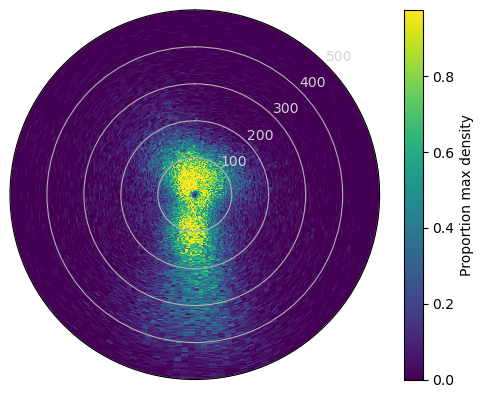

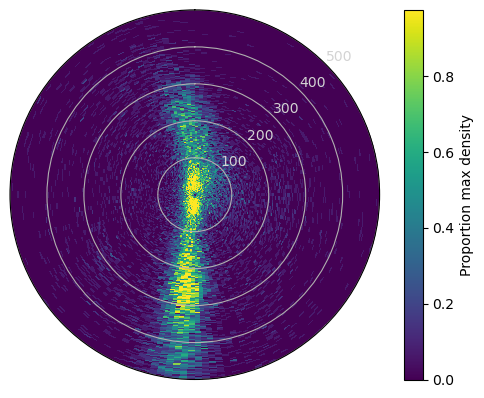

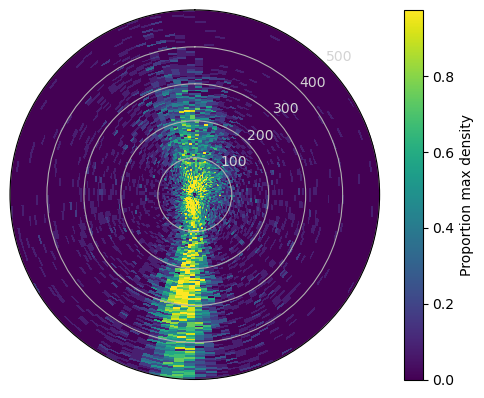

In [10]:
ca1_bins=150
ca2_bins=150
ca3_bins=100
radius_remove=0

vmax_quant=0.975
max_r=500

fig, ax = plt.subplots(subplot_kw={"projection": "polar"})
polar_density_plot(ca1_df,  max_r=max_r ,vmax_quant=vmax_quant, bins=ca1_bins, min_r=radius_remove, theta_col="theta_adj", title="", remove_angles=True, rotation=10, ax=ax)

fig, ax = plt.subplots(subplot_kw={"projection": "polar"})
polar_density_plot(ca2_df,  max_r=max_r ,vmax_quant=vmax_quant, bins=ca2_bins, min_r=radius_remove, theta_col="theta_adj", title="", remove_angles=True, rotation=0, ax=ax)

fig, ax = plt.subplots(subplot_kw={"projection": "polar"})
polar_density_plot(ca3_df,  max_r=max_r ,vmax_quant=vmax_quant, bins=ca3_bins, min_r=radius_remove, theta_col="theta_adj", title="", remove_angles=True, rotation=0, ax=ax)



In [11]:
cluster_df_dgu_non_soma = cluster_df_dgu.loc[~cluster_df_dgu['in_dg_upper']]
cluster_df_dgl_non_soma = cluster_df_dgl.loc[~cluster_df_dgl['in_dg_lower']]

In [12]:

n_bins=25
cluster_df_dgu_non_soma["prop_along_group"] = pd.cut(cluster_df_dgu_non_soma["r"], bins=n_bins, labels=np.arange(0, n_bins, 1))
cluster_df_dgl_non_soma["prop_along_group"] = pd.cut(cluster_df_dgl_non_soma["r"], bins=n_bins, labels=np.arange(0, n_bins, 1))

dgu_adj_angles_d = angle_groups(cluster_df_dgu_non_soma, group_col="prop_along_group", is_apical_col="is_apical")
cluster_df_dgu_non_soma["theta_adj"] = cluster_df_dgu_non_soma.apply(lambda row: add_angles(row["theta"], dgu_adj_angles_d[f"apical_{row['prop_along_group']}"]), axis=1)

dgl_adj_angles_d = angle_groups(cluster_df_dgl_non_soma, group_col="prop_along_group", is_apical_col="is_apical")
cluster_df_dgl_non_soma["theta_adj"] = cluster_df_dgl_non_soma.apply(lambda row: add_angles(row["theta"], dgu_adj_angles_d[f"apical_{row['prop_along_group']}"]), axis=1)



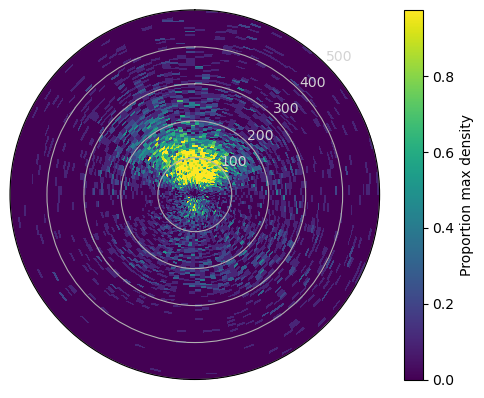

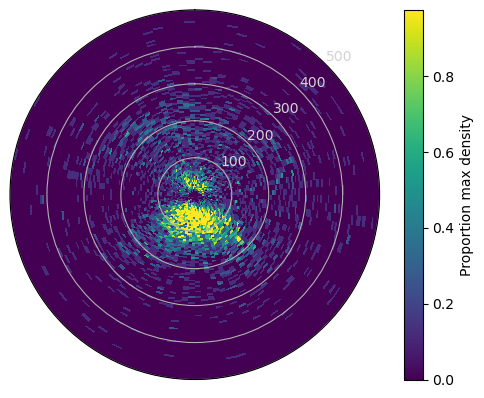

In [13]:
dg_bins=100
vmax_quant=0.975
max_r=500
theta_col = "theta_adj"


fig, ax = plt.subplots(subplot_kw={"projection": "polar"})
upper_dg_boundaries = []
polar_density_plot(cluster_df_dgu_non_soma,  max_r=max_r ,vmax_quant=vmax_quant, bins=dg_bins, min_r=radius_remove, theta_col=theta_col, title="", remove_angles=True, rotation=180, ax=ax, rasterized=True)

fig, ax = plt.subplots(subplot_kw={"projection": "polar"})
polar_density_plot(cluster_df_dgl_non_soma,  max_r=max_r ,vmax_quant=vmax_quant, bins=dg_bins, min_r=radius_remove, theta_col=theta_col, title="", remove_angles=True, rotation=180, ax=ax, rasterized=True)


## Apical/Basal length comparison

In [14]:
"""
Apical: Must be in synaptic plane
Basal: All from source
"""

## take anterior centroids for apical and posterior for basal
ca1_df_anterior = ca1_df.loc[ca1_df["z_centroid_group"].isin([0, 1])]
ca1_df_posterior = ca1_df.loc[ca1_df["z_centroid_group"].isin([2, 3, 4])]

ca2_df_anterior = ca2_df.loc[ca2_df["z_centroid_group"].isin([0, 1])]
ca2_df_posterior = ca2_df.loc[ca2_df["z_centroid_group"].isin([2, 3, 4])]

ca3_df_anterior = ca3_df.loc[ca3_df["z_centroid_group"].isin([0, 1])]
ca3_df_posterior = ca3_df.loc[ca3_df["z_centroid_group"].isin([2, 3, 4])]

ca1_df_filt_apical = ca1_df_anterior.loc[~ca1_df_anterior["match_in_pyr_slim"]]
ca1_df_filt_apical = ca1_df_filt_apical.loc[ca1_df_filt_apical["is_apical_side_plane"]]
ca1_df_filt_apical = ca1_df_filt_apical.loc[ca1_df_filt_apical["match_in_apical_syn_layer"]]

ca2_df_filt_apical = ca2_df_anterior.loc[~ca2_df_anterior["match_in_pyr_slim"]]
ca2_df_filt_apical = ca2_df_filt_apical.loc[ca2_df_filt_apical["is_apical_side_plane"]]
ca2_df_filt_apical = ca2_df_filt_apical.loc[ca2_df_filt_apical["match_in_apical_syn_layer"]]

ca3_df_filt_apical = ca3_df_anterior.loc[~ca3_df_anterior["match_in_pyr_slim"]]
ca3_df_filt_apical = ca3_df_filt_apical.loc[ca3_df_filt_apical["is_apical_side_plane"]]
ca3_df_filt_apical = ca3_df_filt_apical.loc[ca3_df_filt_apical["match_in_apical_syn_layer"]]


ca1_df_filt_basal = ca1_df_posterior.loc[~ca1_df_posterior["is_apical_side_plane"]]
ca1_df_filt_basal = ca1_df_posterior.loc[ca1_df_posterior["match_in_basal_syn_layer"]]


ca2_df_filt_basal = ca2_df_posterior.loc[~ca2_df_posterior["is_apical_side_plane"]]
ca2_df_filt_basal = ca2_df_posterior.loc[ca2_df_posterior["match_in_basal_syn_layer"]]


ca3_df_filt_basal = ca3_df_posterior.loc[~ca3_df_posterior["is_apical_side_plane"]]
ca3_df_filt_basal = ca3_df_posterior.loc[ca3_df_posterior["match_in_basal_syn_layer"]]


ca1_color = "#4273f8"
ca2_color = "#f6b360"
ca3_color = "#f12515"
ref_alpha=1
syn_alpha=1
ref_linestyle = "--"

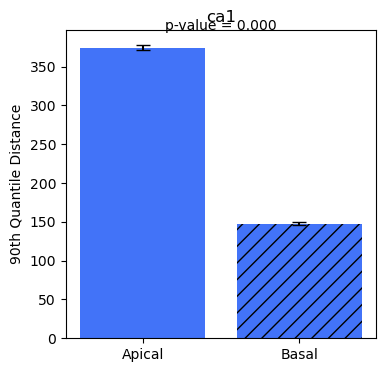

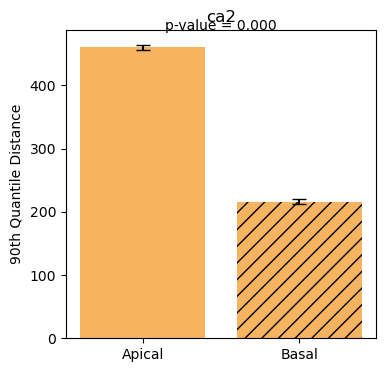

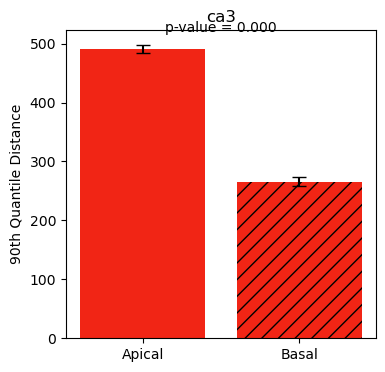

In [15]:
quantile=0.9

fig, ax = plt.subplots(figsize=(4, 4))
plot_distance_quantile_apical_basal(ca1_df_filt_apical, ca1_df_filt_basal, ca1_color, title="ca1", quantile=quantile, ax=ax)


fig, ax = plt.subplots(figsize=(4, 4))
plot_distance_quantile_apical_basal(ca2_df_filt_apical, ca2_df_filt_basal, ca2_color, title="ca2", quantile=quantile, ax=ax)


fig, ax = plt.subplots(figsize=(4, 4))
plot_distance_quantile_apical_basal(ca3_df_filt_apical, ca3_df_filt_basal, ca3_color, title="ca3", quantile=quantile, ax=ax)




## proportion in regions

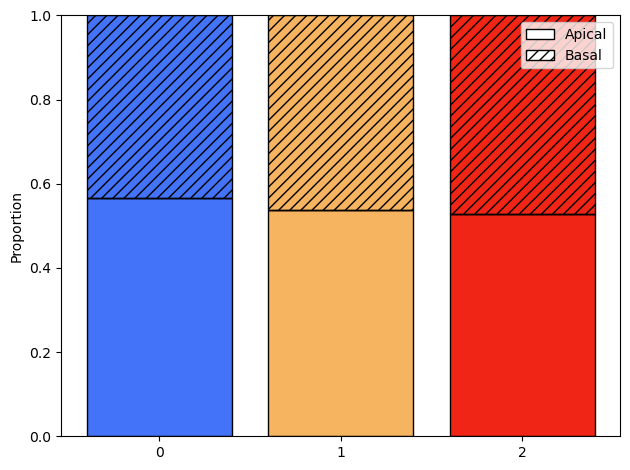

In [51]:
vt_pyr_df_non_soma = vt_pyr_df.loc[~vt_pyr_df["match_in_pyr_slim"]]
is_apical_and_poly = vt_pyr_df_non_soma["is_apical_side_plane"] & vt_pyr_df_non_soma["match_in_apical_syn_layer"]
is_basal_and_poly = ((~vt_pyr_df_non_soma["is_apical_side_plane"]) & vt_pyr_df_non_soma["match_in_basal_syn_layer"])
is_valid = is_apical_and_poly | is_basal_and_poly

vt_pyr_df_syn_layers = vt_pyr_df_non_soma[is_valid]

apical_basal_props_regions = compute_prop_in_field(vt_pyr_df_syn_layers, split_col="mapped_ct_broad")

cell_type_color_d = {"ca1": ca1_color, "ca2": ca2_color, "ca3": ca3_color}
fig, ax = plt.subplots()
plot_prop_apical_basal_from_d(apical_basal_props_regions, title="RCTD-Region", color_dict = cell_type_color_d, ax=ax)

fig.show()


In [ ]:
# Compare PYR to reference

In [95]:

# ref_df_path = "/broad/macosko/jsilverm/10_synapse_seq/objects/reference_construction_points_33125.csv"
ref_df_path = os.path.join(target_path, "reconstructed_neuron_df.csv")
recon_ref_df = pd.read_csv(ref_df_path, index_col=0).reset_index(drop=True)

# right_centroids_w_dr_path = "/broad/macosko/jsilverm/10_synapse_seq/objects/ref_right_centroids_dr.csv"
right_centroids_w_dr_path = os.path.join(target_path, "centroid_locations_dr.csv")
right_centroids_dr_df = pd.read_csv(right_centroids_w_dr_path, index_col=0)



In [ ]:
## Orientation along pyr layer

In [59]:
recon_ref_df_w_cgrid = pd.merge(recon_ref_df, right_centroids_dr_df, on="neuron_id", how="inner", suffixes=(None, "_centroids_dr"))

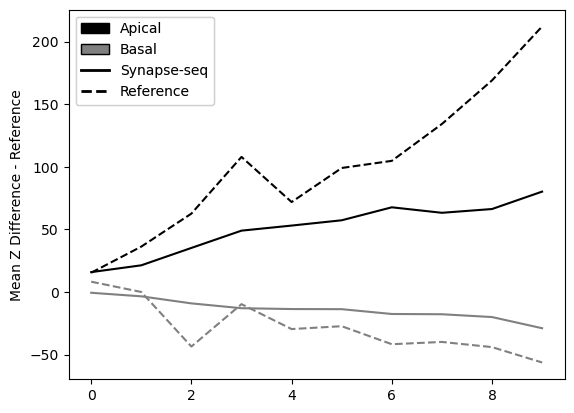

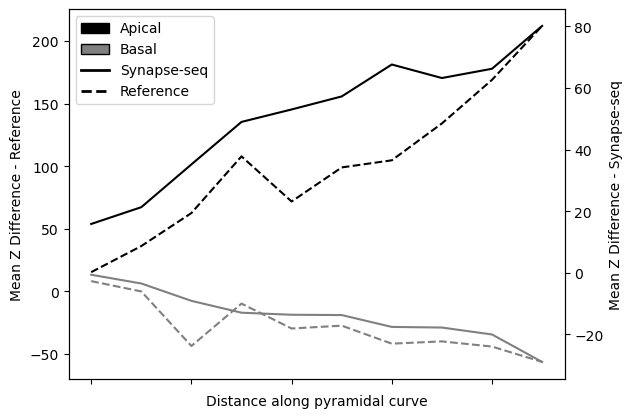

In [61]:
%matplotlib inline

apical_color="black"
basal_color="gray"

right_hemi_points_coords_df = recon_ref_df_w_cgrid.loc[recon_ref_df_w_cgrid["hemi"] == "R"]

right_hemi_points_coords_df["diff_z_signed"] = right_hemi_points_coords_df["z"] - right_hemi_points_coords_df["center_z"]

n_bins = 10
bin_labels = np.arange(0, n_bins)
right_hemi_points_coords_df["r_bin_orien"] = pd.cut(right_hemi_points_coords_df["r"], bins=n_bins, labels=bin_labels).astype(int)

group_along_apical_basal_zdist_ref = right_hemi_points_coords_df.groupby(["r_bin_orien", "is_apical_ref"])["diff_z_signed"].mean().reset_index()
group_along_zdist_apical_ref = group_along_apical_basal_zdist_ref.loc[group_along_apical_basal_zdist_ref["is_apical_ref"]]
group_along_zdist_basal_ref = group_along_apical_basal_zdist_ref.loc[~group_along_apical_basal_zdist_ref["is_apical_ref"]]

vt_pyr_df["r_bin"] = pd.cut(vt_pyr_df["r"], bins=n_bins, labels=bin_labels).astype(int)
vt_pyr_df["diff_z_signed"] = vt_pyr_df["z_coord"] - vt_pyr_df["z_coord_centroid"]


vt_pyr_df_ant = vt_pyr_df.loc[vt_pyr_df["z_centroid_group"].isin([0, 1])]
vt_pyr_df_post = vt_pyr_df.loc[vt_pyr_df["z_centroid_group"].isin([3, 4])]

vt_pyr_df_ant = vt_pyr_df_ant.loc[vt_pyr_df_ant["is_apical_side_plane"]]
vt_pyr_df_post = vt_pyr_df_post.loc[~vt_pyr_df_post["is_apical_side_plane"]]

vt_pyr_df_ant = vt_pyr_df_ant.loc[~vt_pyr_df_ant["in_soma"]]
# vt_pyr_df_post = vt_pyr_df_post.loc[~vt_pyr_df_post["in_soma"]]

group_along_zdist_apical = vt_pyr_df_ant.groupby("r_bin")["diff_z_signed"].mean().reset_index()
group_along_zdist_basal = vt_pyr_df_post.groupby("r_bin")["diff_z_signed"].mean().reset_index()


color_legend = [
 Patch(facecolor=apical_color, edgecolor="black", label="Apical"),
    Patch(facecolor=basal_color, edgecolor="black", label="Basal"),
    Line2D([0], [0], color="black", lw=2, linestyle="-", label="Synapse-seq"),
    Line2D([0], [0], color="black", lw=2, linestyle="--", label="Reference")
]


fig, ax = plt.subplots()
ax.plot(group_along_zdist_apical_ref["r_bin_orien"], group_along_zdist_apical_ref["diff_z_signed"], label="Apical - Reference", alpha=1, color=apical_color, linestyle="--")
ax.plot(group_along_zdist_basal_ref["r_bin_orien"], group_along_zdist_basal_ref["diff_z_signed"], label="Basal Reference", alpha=1, color=basal_color, linestyle="--")

ax.plot(group_along_zdist_apical["r_bin"], group_along_zdist_apical["diff_z_signed"], label="Apical Synapse-seq", color=apical_color, alpha=1)
ax.plot(group_along_zdist_basal["r_bin"], group_along_zdist_basal["diff_z_signed"], label="Basal Synapse-seq", color=basal_color, alpha=1)
ax.set_ylabel("Mean Z Difference - Reference")

# Plot the legends
legend1 = ax.legend(handles=color_legend, loc="upper left")

# Add both legends
ax.add_artist(legend1)
fig.show()


fig, ax = plt.subplots()
ax.plot(group_along_zdist_apical_ref["r_bin_orien"], group_along_zdist_apical_ref["diff_z_signed"], label="Apical - Reference", alpha=1, color=apical_color, linestyle="--")
ax.plot(group_along_zdist_basal_ref["r_bin_orien"], group_along_zdist_basal_ref["diff_z_signed"], label="Basal Reference", alpha=1, color=basal_color, linestyle="--")

ax2 = ax.twinx()

ax2.plot(group_along_zdist_apical["r_bin"], group_along_zdist_apical["diff_z_signed"], label="Apical Synapse-seq", color=apical_color, alpha=1)
ax2.plot(group_along_zdist_basal["r_bin"], group_along_zdist_basal["diff_z_signed"], label="Basal Synapse-seq", color=basal_color, alpha=1)
legend1 = ax.legend(handles=color_legend, loc="upper left")
ax.set_ylabel("Mean Z Difference - Reference")
ax2.set_ylabel("Mean Z Difference - Synapse-seq")
ax.set_xlabel("Distance along pyramidal curve")
ax.set_xticklabels([])


fig.show()



In [ ]:
# Reference comparison Sholl analysis

In [63]:
recon_ref_df_ca1 = recon_ref_df.loc[recon_ref_df["is_ca1"]]
recon_ref_df_ca2 = recon_ref_df.loc[recon_ref_df["is_ca2"]]
recon_ref_df_ca3 = recon_ref_df.loc[recon_ref_df["is_ca3"]]

In [64]:
recon_ref_df_ca1_apical = recon_ref_df_ca1.loc[recon_ref_df_ca1["is_apical_ref"]]
recon_ref_df_ca2_apical = recon_ref_df_ca2.loc[recon_ref_df_ca2["is_apical_ref"]]
recon_ref_df_ca3_apical = recon_ref_df_ca3.loc[recon_ref_df_ca3["is_apical_ref"]]

recon_ref_df_ca1_basal = recon_ref_df_ca1.loc[~recon_ref_df_ca1["is_apical_ref"]]
recon_ref_df_ca2_basal = recon_ref_df_ca2.loc[~recon_ref_df_ca2["is_apical_ref"]]
recon_ref_df_ca3_basal = recon_ref_df_ca3.loc[~recon_ref_df_ca3["is_apical_ref"]]

In [40]:
# """
# Apical: Must be in synaptic plane
# Basal: All from source
# """
# ## take anterior centroids for apical and posterior for basal
# ca1_df_anterior = ca1_df.loc[ca1_df["z_centroid_group"].isin([0, 1])]
# ca1_df_posterior = ca1_df.loc[ca1_df["z_centroid_group"].isin([2, 3, 4])]

# ca2_df_anterior = ca2_df.loc[ca2_df["z_centroid_group"].isin([0, 1])]
# ca2_df_posterior = ca2_df.loc[ca2_df["z_centroid_group"].isin([2, 3, 4])]

# ca3_df_anterior = ca3_df.loc[ca3_df["z_centroid_group"].isin([0, 1])]
# ca3_df_posterior = ca3_df.loc[ca3_df["z_centroid_group"].isin([2, 3, 4])]

# ca1_df_filt_apical = ca1_df_anterior.loc[~ca1_df_anterior["match_in_pyr_slim"]]
# ca1_df_filt_apical = ca1_df_filt_apical.loc[ca1_df_filt_apical["is_apical_side_plane"]]
# ca1_df_filt_apical = ca1_df_filt_apical.loc[ca1_df_filt_apical["match_in_apical_syn_layer"]]

# ca2_df_filt_apical = ca2_df_anterior.loc[~ca2_df_anterior["match_in_pyr_slim"]]
# ca2_df_filt_apical = ca2_df_filt_apical.loc[ca2_df_filt_apical["is_apical_side_plane"]]
# ca2_df_filt_apical = ca2_df_filt_apical.loc[ca2_df_filt_apical["match_in_apical_syn_layer"]]

# ca3_df_filt_apical = ca3_df_anterior.loc[~ca3_df_anterior["match_in_pyr_slim"]]
# ca3_df_filt_apical = ca3_df_filt_apical.loc[ca3_df_filt_apical["is_apical_side_plane"]]
# ca3_df_filt_apical = ca3_df_filt_apical.loc[ca3_df_filt_apical["match_in_apical_syn_layer"]]


# ca1_df_filt_basal = ca1_df_posterior.loc[~ca1_df_posterior["is_apical_side_plane"]]
# ca1_df_filt_basal = ca1_df_posterior.loc[ca1_df_posterior["match_in_basal_syn_layer"]]


# ca2_df_filt_basal = ca2_df_posterior.loc[~ca2_df_posterior["is_apical_side_plane"]]
# ca2_df_filt_basal = ca2_df_posterior.loc[ca2_df_posterior["match_in_basal_syn_layer"]]


# ca3_df_filt_basal = ca3_df_posterior.loc[~ca3_df_posterior["is_apical_side_plane"]]
# ca3_df_filt_basal = ca3_df_posterior.loc[ca3_df_posterior["match_in_basal_syn_layer"]]

# ca1_color = "#4273f8"
# ca2_color = "#f6b360"
# ca3_color = "#f12515"
# ref_alpha=1
# syn_alpha=1
# ref_linestyle = "--"

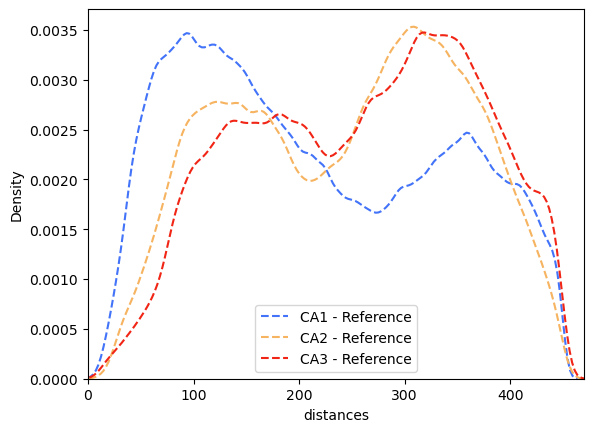

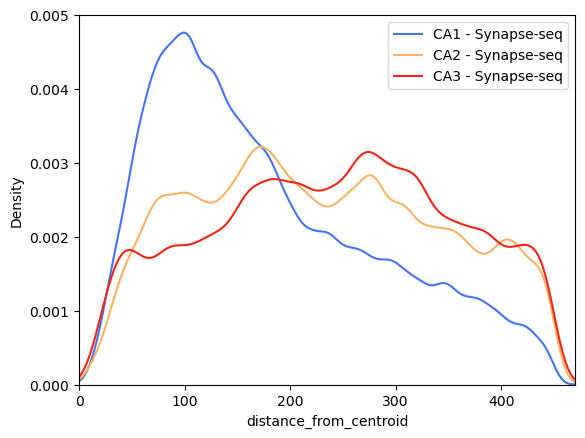

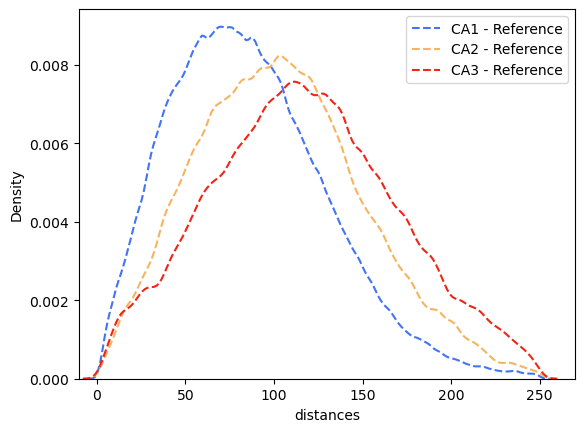

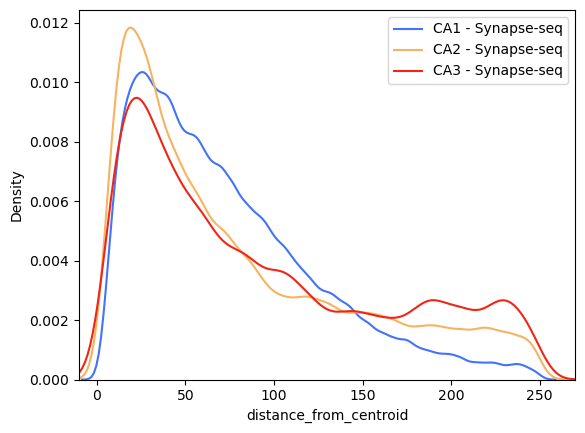

In [66]:
max_distance_apical=450
min_distance = 0
bw_adjust = 0.5

distance_col_ref="distances"
fig, ax = plt.subplots()
compute_density_ap_bas(recon_ref_df_ca1, title="CA1 - Reference", ax=ax, is_apical_col="is_apical_ref", distance_col=distance_col_ref, color=ca1_color, alpha=ref_alpha, max_distance=max_distance_apical, bw_adjust=bw_adjust, linestyle=ref_linestyle)
compute_density_ap_bas(recon_ref_df_ca2, title="CA2 - Reference", ax=ax, is_apical_col="is_apical_ref", distance_col=distance_col_ref, color=ca2_color, alpha=ref_alpha, max_distance=max_distance_apical, bw_adjust=bw_adjust, linestyle=ref_linestyle)
compute_density_ap_bas(recon_ref_df_ca3, title="CA3 - Reference", ax=ax, is_apical_col="is_apical_ref", distance_col=distance_col_ref, color=ca3_color, alpha=ref_alpha, max_distance=max_distance_apical, bw_adjust=bw_adjust, linestyle=ref_linestyle)
ax.set_xlim(0, max_distance_apical+20)
ax.legend()
fig.show()

distance_col_ss="distance_from_centroid"
fig, ax = plt.subplots()
compute_density_ap_bas(ca1_df_filt_apical, title="CA1 - Synapse-seq", ax=ax, is_apical_col="is_apical_side_plane", distance_col=distance_col_ss, color=ca1_color, alpha=syn_alpha, max_distance=max_distance_apical, min_distance=min_distance, bw_adjust=bw_adjust)
compute_density_ap_bas(ca2_df_filt_apical, title="CA2 - Synapse-seq", ax=ax, is_apical_col="is_apical_side_plane", distance_col=distance_col_ss, color=ca2_color, alpha=syn_alpha, max_distance=max_distance_apical, min_distance=min_distance, bw_adjust=bw_adjust)
compute_density_ap_bas(ca3_df_filt_apical, title="CA3 - Synapse-seq", ax=ax, is_apical_col="is_apical_side_plane", distance_col=distance_col_ss, color=ca3_color, alpha=syn_alpha, max_distance=max_distance_apical, min_distance=min_distance, bw_adjust=bw_adjust)
ax.legend()
ax.set_xlim(0, max_distance_apical+20)
fig.show()


max_basal_dist = 250
min_basal_dist=0
fig, ax = plt.subplots()
compute_density_ap_bas(recon_ref_df_ca1, title="CA1 - Reference", ax=ax, is_apical_col="is_apical_ref", distance_col=distance_col_ref, subset_apical=False, max_distance=max_basal_dist, color=ca1_color, alpha=ref_alpha, min_distance=min_basal_dist, linestyle=ref_linestyle, bw_adjust=bw_adjust)
compute_density_ap_bas(recon_ref_df_ca2, title="CA2 - Reference", ax=ax, is_apical_col="is_apical_ref", distance_col=distance_col_ref, subset_apical=False, max_distance=max_basal_dist, color=ca2_color, alpha=ref_alpha, min_distance=min_basal_dist, linestyle=ref_linestyle, bw_adjust=bw_adjust)
compute_density_ap_bas(recon_ref_df_ca3, title="CA3 - Reference", ax=ax, is_apical_col="is_apical_ref", distance_col=distance_col_ref, subset_apical=False,max_distance=max_basal_dist, color=ca3_color, alpha=ref_alpha, min_distance=min_basal_dist, linestyle=ref_linestyle, bw_adjust=bw_adjust)
ax.legend()
ax.set_xlim(-10, max_basal_dist+20)
fig.show()

fig, ax = plt.subplots()
compute_density_ap_bas(ca1_df_filt_basal, title="CA1 - Synapse-seq", ax=ax, is_apical_col="is_apical_side_plane", distance_col=distance_col_ss, subset_apical=False, max_distance=max_basal_dist, color=ca1_color, alpha=syn_alpha, min_distance=min_basal_dist, bw_adjust=bw_adjust, x_tick_width=10)
compute_density_ap_bas(ca2_df_filt_basal, title="CA2 - Synapse-seq", ax=ax, is_apical_col="is_apical_side_plane", distance_col=distance_col_ss, subset_apical=False, max_distance=max_basal_dist, color=ca2_color, alpha=syn_alpha, min_distance=min_basal_dist, bw_adjust=bw_adjust)
compute_density_ap_bas(ca3_df_filt_basal, title="CA3 - Synapse-seq", ax=ax, is_apical_col="is_apical_side_plane", distance_col=distance_col_ss, subset_apical=False,max_distance=max_basal_dist, color=ca3_color, alpha=syn_alpha, min_distance=min_basal_dist, bw_adjust=bw_adjust)
ax.set_xlim(-10, max_basal_dist+20)
ax.legend()
fig.show()


## Compare relative distributions

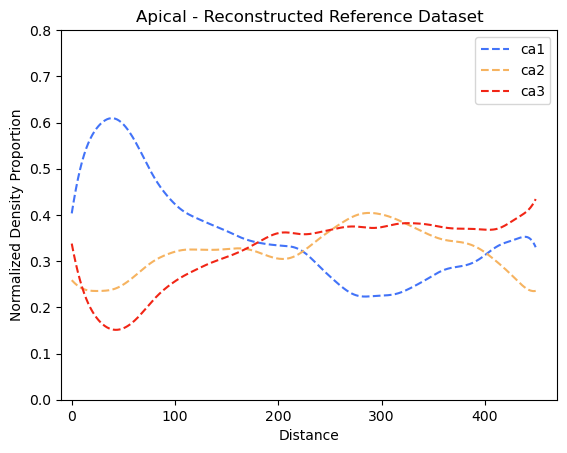

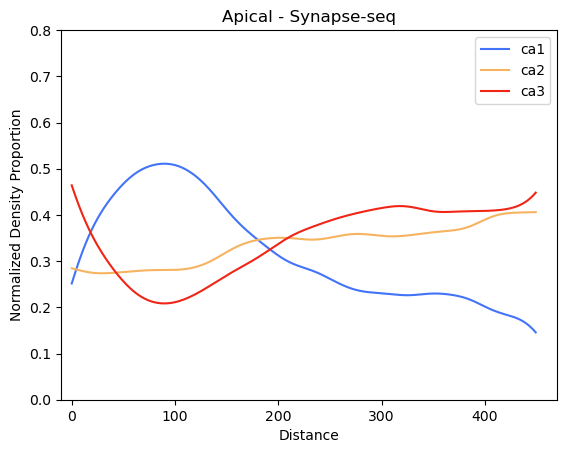

In [67]:
max_distance=450
min_distance=0
color_dict = {"ca1": ca1_color, "ca2": ca2_color, "ca3": ca3_color}

# apical relative differences
ca1_distances = recon_ref_df_ca1.loc[recon_ref_df_ca1["is_apical_ref"], "distances"]
ca2_distances = recon_ref_df_ca2.loc[recon_ref_df_ca2["is_apical_ref"], "distances"]
ca3_distances = recon_ref_df_ca3.loc[recon_ref_df_ca3["is_apical_ref"], "distances"]

ref_distance_vec_d = {"ref_ca1": ca1_distances, "ref_ca2": ca2_distances, "ref_ca3": ca3_distances}

ss_distance_col="distance_from_centroid"
ca1_distances_ss = ca1_df_filt_apical.loc[ca1_df_filt_apical["is_apical_side_plane"], ss_distance_col]
ca2_distances_ss = ca2_df_filt_apical.loc[ca2_df_filt_apical["is_apical_side_plane"], ss_distance_col]
ca3_distances_ss = ca3_df_filt_apical.loc[ca3_df_filt_apical["is_apical_side_plane"], ss_distance_col]

distance_vec_d_ss = {"ss_ca1": ca1_distances_ss, "ss_ca2": ca2_distances_ss, "ss_ca3": ca3_distances_ss}

fig, ax = plt.subplots()
compute_relative_normalized_density(ref_distance_vec_d, min_distance=min_distance, max_distance=max_distance, title="Apical - Reconstructed Reference Dataset", color_dict=color_dict, linestyle="--", ax=ax)
ax.set_xlim(-10, max_distance+20)
fig.show()

fig, ax = plt.subplots()
compute_relative_normalized_density(distance_vec_d_ss, min_distance=min_distance, max_distance=max_distance, title="Apical - Synapse-seq", color_dict=color_dict, ax=ax)
ax.set_xlim(-10, max_distance+20)

fig.show()


# DG Sholl Analysis

In [69]:

dgu_color = "gray"
dgl_color = "black"


cluster_df_dgu["dg_region"] = "Upper"
cluster_df_dgl["dg_region"] = "Lower"

comb_dg_df = pd.concat([cluster_df_dgu, cluster_df_dgl], axis=0)

# dgu_no_soma = cluster_df_dgu.loc[~cluster_df_dgu["in_dg"]]
dgu_no_soma = cluster_df_dgu.loc[cluster_df_dgu["is_apical"]]
# dgl_no_soma = cluster_df_dgl.loc[~cluster_df_dgl["in_dg"]]
dgl_no_soma = cluster_df_dgl.loc[cluster_df_dgl["is_apical"]]

distance_col="distance_from_centroid"
NBOOT=1000
eval_inc=1
bandwidth=5
min_val=0
max_val=250

dgu_kde_ci = compute_confidence_intervals_kde(dgu_no_soma, distance_col=distance_col, max_val=max_val, min_val=min_val, bandwidth=bandwidth, eval_inc=eval_inc, NBOOT=NBOOT)
dgl_kde_ci = compute_confidence_intervals_kde(dgl_no_soma, distance_col=distance_col, max_val=max_val, min_val=min_val, bandwidth=bandwidth, eval_inc=eval_inc, NBOOT=NBOOT)



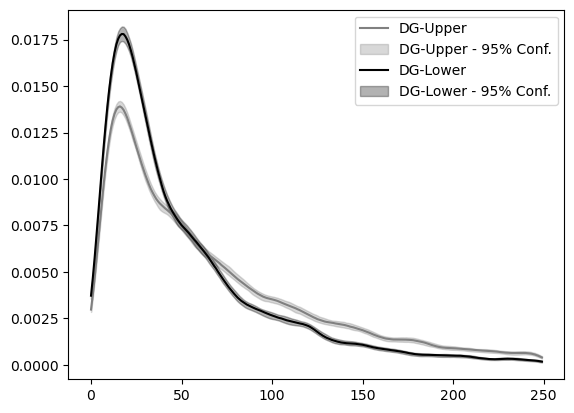

In [71]:

fig, ax = plt.subplots()
plot_dist_w_conf_intervals(dgu_kde_ci, label="DG-Upper", color=dgu_color, xcol="distance", ax=ax)
plot_dist_w_conf_intervals(dgl_kde_ci, label="DG-Lower", color=dgl_color, xcol="distance", ax=ax)
fig.show()


# Superficial and Deep Subfields

In [10]:
super_color = "#328c8e"
deep_color = "#800074"

In [17]:
"""
Filter steps:
1.) Only analyze beads in apical synaptic field (defined by polygon)
2.) Only apical calls (likely subset of the above filter
3.) Not in the soma (pyr) layer
"""

region_col = "mapped_ct_broad"

vt_pyr_df_apical_valid = vt_pyr_df.loc[vt_pyr_df["match_in_apical_syn_layer"]]
vt_pyr_df_apical_valid = vt_pyr_df_apical_valid.loc[vt_pyr_df_apical_valid['is_apical_side_plane']]
vt_pyr_df_apical_valid = vt_pyr_df_apical_valid.loc[~vt_pyr_df_apical_valid["match_in_pyr_slim"]]

vt_df_ca1_apical = vt_pyr_df_apical_valid.loc[vt_pyr_df_apical_valid[region_col] == "ca1"]
vt_df_ca2_apical = vt_pyr_df_apical_valid.loc[vt_pyr_df_apical_valid[region_col] == "ca2"]
vt_df_ca3_apical = vt_pyr_df_apical_valid.loc[vt_pyr_df_apical_valid[region_col] == "ca3"]


In [18]:
"""
Only consider points beyond 40um to account for excess soma signal
"""
min_dist_to_curve = 40

vt_df_ca1_apical_filt_far = vt_df_ca1_apical[vt_df_ca1_apical["distance_curve_lower"] > min_dist_to_curve]
vt_df_ca2_apical_filt_far = vt_df_ca2_apical[vt_df_ca2_apical["distance_curve_lower"] > min_dist_to_curve]
vt_df_ca3_apical_filt_far = vt_df_ca3_apical[vt_df_ca3_apical["distance_curve_lower"] > min_dist_to_curve]



In [19]:
z_group_col='z_centroid_group'
sup_deep_col="sup_deep_d"
z_groups = [0, 1]


vt_df_ca1_ant = vt_df_ca1_apical_filt_far.loc[vt_df_ca1_apical_filt_far[z_group_col].isin(z_groups)]

vt_df_ca2_ant = vt_df_ca2_apical_filt_far.loc[vt_df_ca2_apical_filt_far[z_group_col].isin(z_groups)]

vt_df_ca3_ant = vt_df_ca3_apical_filt_far.loc[vt_df_ca3_apical_filt_far[z_group_col].isin(z_groups)]

vt_df_ca1_deep = vt_df_ca1_ant.loc[vt_df_ca1_ant[sup_deep_col] == "Deep"]
vt_df_ca1_super = vt_df_ca1_ant.loc[vt_df_ca1_ant[sup_deep_col] == "Super"]

vt_df_ca2_deep = vt_df_ca2_ant.loc[vt_df_ca2_ant[sup_deep_col] == "Deep"]
vt_df_ca2_super = vt_df_ca2_ant.loc[vt_df_ca2_ant[sup_deep_col] == "Super"]

vt_df_ca3_deep = vt_df_ca3_ant.loc[vt_df_ca3_ant[sup_deep_col] == "Deep"]
vt_df_ca3_super = vt_df_ca3_ant.loc[vt_df_ca3_ant[sup_deep_col] == "Super"]


In [20]:
distance_col = "distance_curve_lower"
max_val = 400
min_val=40
NBOOT=100
bandwidth=15
eval_inc=1


ca1_deep_kde_ci = compute_confidence_intervals_kde(vt_df_ca1_deep, distance_col=distance_col, max_val=max_val, min_val=min_val, bandwidth=bandwidth, eval_inc=eval_inc, NBOOT=NBOOT)
ca1_super_kde_ci = compute_confidence_intervals_kde(vt_df_ca1_super, distance_col=distance_col, max_val=max_val, min_val=min_val, bandwidth=bandwidth, eval_inc=eval_inc, NBOOT=NBOOT)

ca2_deep_kde_ci = compute_confidence_intervals_kde(vt_df_ca2_deep, distance_col=distance_col, max_val=max_val, min_val=min_val, bandwidth=bandwidth, eval_inc=eval_inc, NBOOT=NBOOT)
ca2_super_kde_ci = compute_confidence_intervals_kde(vt_df_ca2_super, distance_col=distance_col, max_val=max_val, min_val=min_val, bandwidth=bandwidth, eval_inc=eval_inc, NBOOT=NBOOT)

ca3_deep_kde_ci = compute_confidence_intervals_kde(vt_df_ca3_deep, distance_col=distance_col, max_val=max_val, min_val=min_val, bandwidth=bandwidth, eval_inc=eval_inc, NBOOT=NBOOT)
ca3_super_kde_ci = compute_confidence_intervals_kde(vt_df_ca3_super, distance_col=distance_col, max_val=max_val, min_val=min_val, bandwidth=bandwidth, eval_inc=eval_inc, NBOOT=NBOOT)



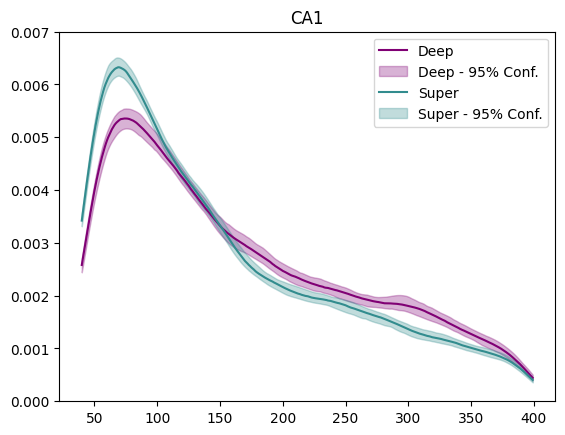

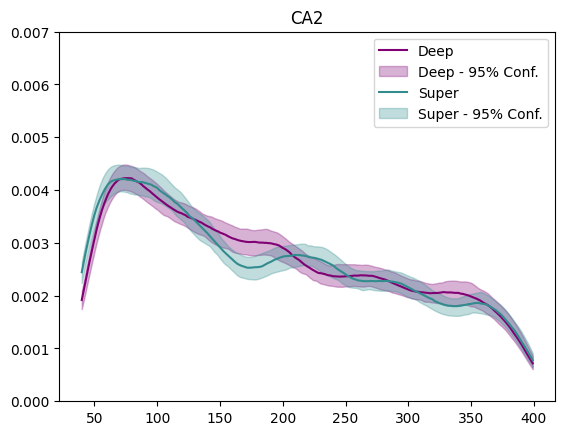

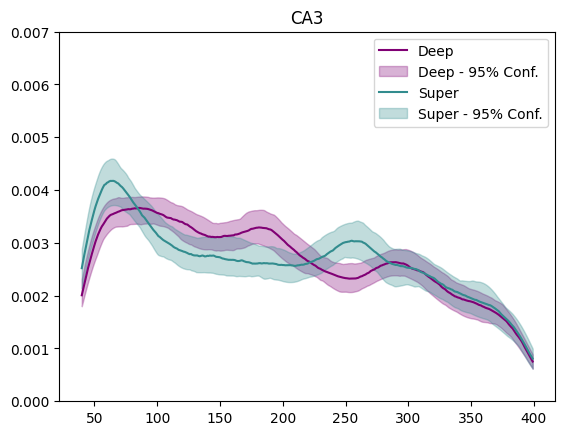

In [21]:
ylim = 0.007
fig, ax = plt.subplots()
plot_dist_w_conf_intervals(ca1_deep_kde_ci, label="Deep", color=deep_color, xcol="distance", ax=ax)
plot_dist_w_conf_intervals(ca1_super_kde_ci, label="Super", color=super_color, xcol="distance", ax=ax)
ax.set_title("CA1")
ax.set_ylim(0, ylim)
fig.show()

fig, ax = plt.subplots()
plot_dist_w_conf_intervals(ca2_deep_kde_ci, label="Deep", color=deep_color, xcol="distance", ax=ax)
plot_dist_w_conf_intervals(ca2_super_kde_ci, label="Super", color=super_color, xcol="distance", ax=ax)
ax.set_title("CA2")
ax.set_ylim(0, ylim)
fig.show()

fig, ax = plt.subplots()
plot_dist_w_conf_intervals(ca3_deep_kde_ci, label="Deep", color=deep_color, xcol="distance", ax=ax)
plot_dist_w_conf_intervals(ca3_super_kde_ci, label="Super", color=super_color, xcol="distance", ax=ax)
ax.set_title("CA3")
ax.set_ylim(0, ylim)
fig.show()


In [78]:
NBOOT=1000
#downsample to CA2
y_lim = 0.007
np.random.seed(0)
target_deep_size = vt_df_ca2_deep.shape[0]
target_super_size = vt_df_ca2_super.shape[0]

# ca1_deep_sampling = np.random.choice(vt_df_ca1_deep.shape[0], target_deep_size, replace=True)
# ca1_super_sampling = np.random.choice(vt_df_ca1_super.shape[0], target_super_size, replace=True)

# vt_df_ca1_deep_sampled = vt_df_ca1_deep.iloc[ca1_deep_sampling]
# vt_df_ca1_super_sampled = vt_df_ca1_super.iloc[ca1_super_sampling]

ca1_deep_kde_ci = compute_confidence_intervals_kde(vt_df_ca1_deep, distance_col=distance_col, max_val=max_val, min_val=min_val, bandwidth=bandwidth, eval_inc=eval_inc, NBOOT=NBOOT, n_sample_to=target_deep_size)
ca1_super_kde_ci = compute_confidence_intervals_kde(vt_df_ca1_super, distance_col=distance_col, max_val=max_val, min_val=min_val, bandwidth=bandwidth, eval_inc=eval_inc, NBOOT=NBOOT, n_sample_to=target_super_size)


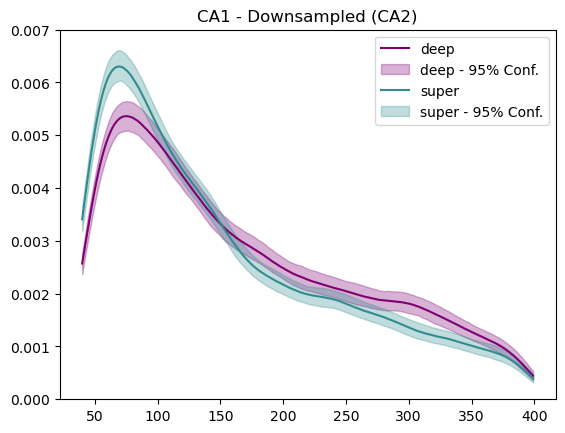

In [79]:

fig, ax = plt.subplots()
plot_dist_w_conf_intervals(ca1_deep_kde_ci, label="deep", color=deep_color, xcol="distance", ax=ax)
plot_dist_w_conf_intervals(ca1_super_kde_ci, label="super", color=super_color, xcol="distance", ax=ax)
ax.set_ylim(0, y_lim)
ax.set_title("CA1 - Downsampled (CA2)")
fig.show()


In [80]:
max_distance_apical = 400
NBOOT=1000

ca1_apical_res, ca1_apical_dist = conf_interval_bootstrap(vt_df_ca1_super, vt_df_ca1_deep, distance_col="distance_curve_lower", max_distance=max_distance_apical, NBOOT=NBOOT)
ca2_apical_res, ca2_apical_dist = conf_interval_bootstrap(vt_df_ca2_super, vt_df_ca2_deep, distance_col="distance_curve_lower", max_distance=max_distance_apical, NBOOT=NBOOT)
ca3_apical_res, ca3_apical_dist = conf_interval_bootstrap(vt_df_ca3_super, vt_df_ca3_deep, distance_col="distance_curve_lower", max_distance=max_distance_apical, NBOOT=NBOOT)



In [81]:
wasserstein_plotting_d = {
    "ca1": {
        "pe": ca1_apical_res["point_estimate"], "se": ca1_apical_res["se"] 
    },
    "ca2": {
        "pe": ca2_apical_res["point_estimate"], "se": ca2_apical_res["se"]
    },
    "ca3": {
        "pe": ca3_apical_res["point_estimate"], "se": ca3_apical_res["se"]
    }
}


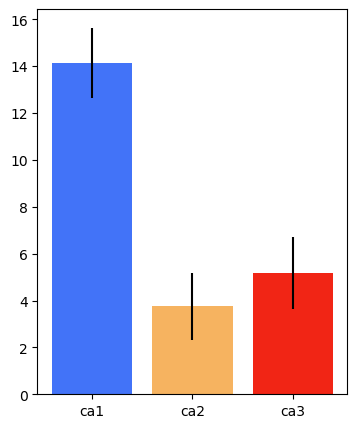

In [83]:

color_d = {"ca1": ca1_color, "ca2": ca2_color, "ca3": ca3_color}

fig, ax = plt.subplots(figsize=(4,5))
plot_barplot_wasserstein(wasserstein_plotting_d, color_d, width=0.7, two_sided_error=False, ax=ax)



### Proportion in fields super/deep

In [84]:

min_dist_border = 40

is_apical_polygon = vt_pyr_df["match_in_apical_syn_layer"]
is_basal_polygon = vt_pyr_df["match_in_basal_syn_layer"]

is_valid_lower = ((vt_pyr_df["distance_curve_lower"] > min_dist_border) & is_apical_polygon)
is_valid_upper = ((vt_pyr_df["distance_curve_upper"] > min_dist_border) & is_basal_polygon)
is_valid = is_valid_lower | is_valid_upper
vt_df_selected_border_filt = vt_pyr_df.loc[is_valid]

vt_df_selected_border_filt = vt_df_selected_border_filt.loc[~vt_df_selected_border_filt["is_apical_polygon"].isna()]
vt_df_selected_border_filt = vt_df_selected_border_filt.loc[~vt_df_selected_border_filt["match_in_pyr_slim"]]



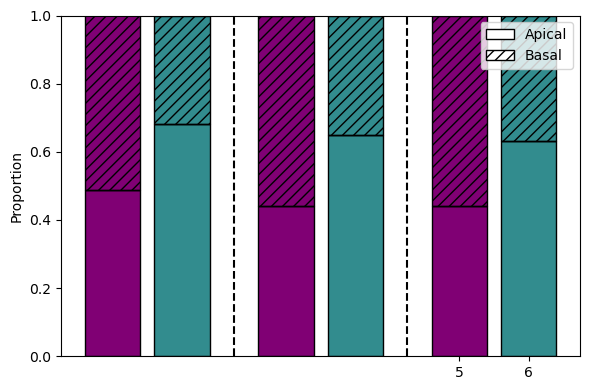

In [85]:
ca1_selected_df = vt_df_selected_border_filt.loc[vt_df_selected_border_filt["mapped_ct_broad"] == "ca1"]
ca2_selected_df = vt_df_selected_border_filt.loc[vt_df_selected_border_filt["mapped_ct_broad"] == "ca2"]
ca3_selected_df = vt_df_selected_border_filt.loc[vt_df_selected_border_filt["mapped_ct_broad"] == "ca3"]

apical_basal_props_ca1 = compute_prop_in_field(ca1_selected_df, split_col="sup_deep_d")
apical_basal_props_ca2 = compute_prop_in_field(ca2_selected_df, split_col="sup_deep_d")
apical_basal_props_ca3 = compute_prop_in_field(ca3_selected_df, split_col="sup_deep_d")


width=0.5
sup_deep_d = {"Super": super_color, "Deep": deep_color}
fig, ax = plt.subplots(figsize=(6,4))
plot_prop_apical_basal_from_d(apical_basal_props_ca1, title="CA1", color_dict = sup_deep_d, ax=ax)

ax.axvline(x=1.75, linestyle="--", color="black")

plot_prop_apical_basal_from_d(apical_basal_props_ca2, title="CA2", color_dict = sup_deep_d, ax=ax, x_start_inx=2.5)
ax.axvline(x=4.25, linestyle="--", color="black")

plot_prop_apical_basal_from_d(apical_basal_props_ca3, title="CA3", color_dict = sup_deep_d, ax=ax, x_start_inx = 5)
fig.show()
